# 06 — 1DCNN 모델 학습 / 평가

DL 첫 모델. dataset_DL/의 사전 변환된 sliding window 데이터로 1DCNN 학습.
Static / Expanding 두 protocol을 **별도 cell**에서 실행 (시간 비용 차이가 큼).

## 산출물
- `results/dl_results_{core,momentum,extended}.csv` — ML 결과 schema + `L` 컬럼 추가
- `results/best_dl_models/1DCNN_{regime}_{country}_{tier}_L{L}.pt` — 학습된 state_dict
- `log/1DCNN/log_1DCNN_{regime}_{country}.csv` — 시계열 예측 (ML과 동일 형식)

## 실행 흐름
1. **Static cell** (★ Cell 10) — 108 모델 학습 (CPU ~30분, Colab GPU ~5분)
2. **Save static** (Cell 12) — 결과 CSV + log 저장
3. **Expanding cell** (★ Cell 14, 별도) — 108 × refit 반복 (CPU ~수십시간, Colab GPU ~수시간)
4. **Append expanding** (Cell 16) — 기존 CSV에 protocol=expanding 추가

Static만 먼저 끝내고 결과 확인 후 expanding 돌릴지 결정 권장.

In [1]:
from IPython.core.debugger import re
import os, sys
from pathlib import Path

# Colab인 경우 Drive 마운트
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    os.environ['FINTEL_PROJECT_ROOT'] = '/content/drive/MyDrive/FINTEL'
except ImportError:
    pass

PROJECT_ROOT = Path(os.environ.get('FINTEL_PROJECT_ROOT', Path.cwd().parent))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

# Change current directory to PROJECT_ROOT to ensure requirements.txt is found
os.chdir(PROJECT_ROOT)

!pip install -r requirements.txt

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/FINTEL
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 42.8 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import sys
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# notebooks/ 안에서 실행될 때 project root 찾기
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.dl import load_one
from src.models.dl import CNN1DModel
from src.eval.metrics import evaluate
from src.eval.phases import iter_phases

from warnings import filterwarnings
filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__}, device={DEVICE}')
print(f'REGIMES = {config.REGIMES}')
print(f'COUNTRIES = {config.COUNTRIES}')

PROJECT_ROOT = /content/drive/MyDrive/FINTEL
torch 2.10.0+cu128, device=cuda
REGIMES = ['normal', '911', 'gfc', 'covid']
COUNTRIES = ['US', 'KR', 'JP']


In [3]:
# ── Google Drive 마운트 (Colab) ─────────────────────────────────────────
# 로컬 환경에서는 자동으로 건너뜀
import shutil

DRIVE_RESULTS = None   # Drive 연결 전 기본값

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    # ★ 본인 Drive 내 FINTEL 경로로 수정하세요
    DRIVE_RESULTS = Path('/content/drive/MyDrive/FINTEL/results')
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
    print(f'Drive 마운트 성공 → {DRIVE_RESULTS}')
except ImportError:
    print('로컬 환경 — Drive 저장 건너뜀')

def save_to_drive(src_dir: Path, patterns=('*.csv',), label=''):
    if DRIVE_RESULTS is None:
        return
    copied = []
    for pat in patterns:
        for f in src_dir.glob(pat):
            dst = DRIVE_RESULTS / f.name
            if f.resolve() == dst.resolve():
                continue
            shutil.copy2(f, dst)
            copied.append(f.name)
    if copied:
        print(f'  Drive 저장({label}): {copied}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive 마운트 성공 → /content/drive/MyDrive/FINTEL/results


## 설정 (plan에 따라 단일 고정)

| 항목 | 값 | 비고 |
|---|---|---|
| Optimizer | AdamW(lr=1e-3, wd=1e-5) | |
| Scheduler | ReduceLROnPlateau(factor=0.5, patience=5) | |
| Loss | MSE | QLIKE는 평가용으로만 |
| Activation | ReLU | 1DCNN 출력 후 FC 직전 |
| Hidden channels | 64 | |
| Num layers | 3 | |
| Dropout | 0.2 | matmul 다음 |
| Kernel size | 3 | causal padding + dilation |
| Batch size | 64 | shuffle=False (시계열) |
| Max epochs | 100 + early stop patience 10 | |
| Gradient clip | norm 1.0 | 1DCNN exploding 방지 |
| Seed | 42 | deterministic |

## L (lookback) — 유일한 hyperparameter
**L ∈ {22, 60, 252} 3개 모두 학습**. cell당 3 row 결과.

## 학습 단위
4 regime × 3 country × 3 tier × 3 L = **108 모델** (static cell당, expanding은 동일 108 × refit).

In [4]:
import json

# === L grid (유일한 hyperparameter 차원) ===
LS = [22, 60, 252]
REGIMES = config.REGIMES        # ['normal', '911', 'gfc', 'covid']
COUNTRIES = config.COUNTRIES    # ['US', 'KR', 'JP']
TIERS = ['core', 'momentum', 'extended']

# === 1DCNN hyperparameter (단일 고정) ===
HP = dict(
    # architecture
    hidden_channels=64,
    num_layers=6,   # causal dilated: RF=253, L=252까지 전체 커버
    kernel_size=3,
    dropout=0.2,
    # optimizer
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=64,
    # training control
    max_epochs=100,
    early_stop_patience=10,
    early_stop_min_delta=1e-5,
    early_stop_metric='qlike',   # ML 정합: best epoch = valid QLIKE 최저
    # scheduler (ReduceLROnPlateau)
    lr_patience=5,
    lr_factor=0.5,
    lr_min=1e-6,
    # regularization
    grad_clip=1.0,
    # reproducibility
    seed=42,
)

# === 출력 경로 ===
RESULTS_DIR = PROJECT_ROOT / 'results'
DL_MODELS_DIR = RESULTS_DIR / 'best_dl_models'
LOG_DIR = PROJECT_ROOT / 'log' / '1DCNN'
DL_MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# === HP를 JSON으로 저장 (재현용) ===
hp_path = RESULTS_DIR / 'dl_hp_config.json'
with open(hp_path, 'w', encoding='utf-8') as f:
    json.dump({'LS': LS, 'TIERS': TIERS, 'HP': HP}, f, indent=2)
print(f'HP config 저장: {hp_path}')
print(f'RESULTS_DIR = {RESULTS_DIR}')
print(f'DL_MODELS_DIR = {DL_MODELS_DIR}')
print(f'LOG_DIR = {LOG_DIR}')

HP config 저장: /content/drive/MyDrive/FINTEL/results/dl_hp_config.json
RESULTS_DIR = /content/drive/MyDrive/FINTEL/results
DL_MODELS_DIR = /content/drive/MyDrive/FINTEL/results/best_dl_models
LOG_DIR = /content/drive/MyDrive/FINTEL/log/1DCNN


## 1D-CNN 구조

```
Input (B, L, F)
  ↓ transpose(1, 2) → (B, F, L)  # Conv1d format
  ↓
CausalDilatedConv(F → 64, k=3, d=1)  → Chomp → ReLU → Dropout   # layer 0, d=1
CausalDilatedConv(64→ 64, k=3, d=2)  → Chomp → ReLU → Dropout   # layer 1, d=2
CausalDilatedConv(64→ 64, k=3, d=4)  → Chomp → ReLU → Dropout   # layer 2, d=4
CausalDilatedConv(64→ 64, k=3, d=8)  → Chomp → ReLU → Dropout   # layer 3, d=8
CausalDilatedConv(64→ 64, k=3, d=16) → Chomp → ReLU → Dropout   # layer 4, d=16
CausalDilatedConv(64→ 64, k=3, d=32) → Chomp → ReLU → Dropout   # layer 5, d=32
  ↓ (B, 64, L)
out[:, :, -1] → (B, 64)        # 마지막 timestep (causal: 미래 정보 차단)
  ↓
nn.Linear(64 → 1) → squeeze → (B,)     # 다음날 RV 예측
```

- **Causal padding**: 왼쪽에만 (k-1)*d 패딩 후 Chomp로 오른쪽 잘라냄 → 미래 정보 차단
- **Dilation** 지수 증가 (1,2,4,8,16,32): RF = 1+2×2×63 = **253** → L=252 전체 커버
- **Residual 없음**: TCN과의 구조적 차이 (TCN은 block당 conv 2개 + residual)
- **WeightNorm** (TCN과 동일 패턴) — 시계열 batch 통계 불안정성 회피, 작은 dataset에 안정
- 이전 same-padding은 마지막 timestep 기준 실효 lookback = num_layers+1 = 4에 불과 (수정됨)

정의는 `src/models/dl/cnn1d.py` 의 `CNN1DNet` + `CNN1DModel`.

In [5]:
# CNN1DModel은 src/models/dl/1dcnn.py에서 import 완료
print(CNN1DModel.__doc__.splitlines()[0])
print(f'name = {CNN1DModel.name}')

1D-CNN 학습/예측 wrapper.
name = 1DCNN


## 헬퍼

- `load_one(regime, country, L, tier)` — 한 cell 로드 + tier subset + scaling (train fit, valid/test transform)
- `eval_phases(splits, y_pred, regime)` — phase별 (Full Test + sub-phase) 4지표 계산해서 dict 리스트 반환

phase 정의는 `src/config.py:PHASES` (regime별).

In [6]:
def eval_phases(splits: dict, y_pred: np.ndarray, regime: str) -> list:
    """phase별 4지표 계산 → list of dicts (각 dict는 한 phase의 결과)."""
    # iter_phases는 DatetimeIndex를 가진 DataFrame을 받음 → dummy
    test_dates = pd.to_datetime(splits['test_meta']['prediction_date'])
    dummy_df = pd.DataFrame(index=pd.DatetimeIndex(test_dates))

    rows = []
    for phase_name, mask, _color in iter_phases(dummy_df, regime):
        if mask.sum() == 0:
            continue
        m = evaluate(splits['test_y'][mask], y_pred[mask])
        rows.append({'phase': phase_name, **m})
    return rows

# 간단 test
splits_test = load_one('normal', 'US', L=22, tier='core')
y_dummy = np.ones_like(splits_test['test_y']) * splits_test['test_y'].mean()
print('test eval_phases 출력 예시:')
for row in eval_phases(splits_test, y_dummy, 'normal'):
    print(f"  {row}")

test eval_phases 출력 예시:
  {'phase': 'Full Test', 'RMSE': 0.38095280663912057, 'MAE': 0.25587374684258246, 'QLIKE': 0.14765303111330233, 'RMSE_CV': 0.6511129245400504}


## ★ STATIC 학습 (108 모델, 1회 실행)

**예상 소요 시간**:
- CPU: 30분 ~ 1시간
- Colab T4 GPU: 5 ~ 15분

각 cell 학습 후 다음 출력:
- `epochs_used` (early stop 발동 시점)
- `best_val_loss` (early stop 시점 best valid MSE)
- `RMSE_CV` (Full Test phase 기준)

결과 row + state_dict는 메모리에 누적되고, 다음 cell에서 저장.

In [ ]:
# 한 (regime, country, tier) 셀당 3단계:
#   1. tuning: L 3개 모두 train fit + valid early stop → best_val_loss 비교
#   2. best L 선택 (valid loss 최저)
#   3. final fit: best L로 (train + valid) combined fit, max_epochs = tuning best_epoch
#   4. test predict + 결과 저장
# 최종 결과는 cell당 1 모델 (best L의 final fit). 모든 L의 tuning 정보는 dl_tuned_L.csv에 별도.

results_static = []
log_static = {}        # (regime, country) → list of DataFrame (RV_target, RV_pred)
history_static = []    # tuning + final 모두 (stage 컬럼으로 구분)
tuning_log = []        # 모든 L의 valid loss (dl_tuned_L.csv용)

total = len(REGIMES) * len(COUNTRIES) * len(TIERS)   # 36 cells (L loop 안에 포함)
i_total = 0
t_start = time.time()

for regime in REGIMES:
    for country in COUNTRIES:
        for tier in TIERS:
            i_total += 1
            t0 = time.time()

            # === 1. Tuning step — L별 train fit + valid early stop + valid QLIKE 측정 ===
            tuning_results = {}    # L → dict
            for L in LS:
                splits_tune = load_one(regime, country, L, tier)
                m_tune = CNN1DModel(
                    feature_cols=splits_tune['feature_cols'],
                    L=L, device=DEVICE, verbose=False, **HP,
                )
                m_tune.fit(
                    splits_tune['train_X'], splits_tune['train_y'],
                    splits_tune['valid_X'], splits_tune['valid_y'],
                )
                # best_val_qlike_ = best epoch (valid QLIKE 최저 epoch) 의 valid QLIKE
                # best_val_mse_   = 같은 best epoch의 valid MSE (참고용)
                # 추가로 valid 4 metric 모두 측정 (RMSE / RMSE_CV 분석용)
                y_valid_pred = m_tune.predict(splits_tune['valid_X'])
                val_metrics = evaluate(splits_tune['valid_y'], y_valid_pred)

                tuning_results[L] = {
                    'val_qlike': float(m_tune.best_val_qlike_),   # ← best L 선택 기준
                    'val_mse': float(m_tune.best_val_mse_),
                    'val_rmse': float(val_metrics['RMSE']),
                    'val_rmse_cv': float(val_metrics['RMSE_CV']),
                    'best_epoch': int(m_tune.best_epoch_),
                    'epochs_used': int(m_tune.epochs_used_),
                }
                tuning_log.append({
                    'regime': regime, 'country': country, 'feature_set': tier, 'L': L,
                    'val_qlike': float(m_tune.best_val_qlike_),
                    'val_mse': float(m_tune.best_val_mse_),
                    'val_rmse': float(val_metrics['RMSE']),
                    'val_rmse_cv': float(val_metrics['RMSE_CV']),
                    'best_epoch': int(m_tune.best_epoch_),
                    'epochs_used': int(m_tune.epochs_used_),
                })
                # tuning history
                hist = m_tune.history_df()
                hist.insert(0, 'stage', 'tuning')
                hist.insert(0, 'L', L)
                hist.insert(0, 'feature_set', tier)
                hist.insert(0, 'country', country)
                hist.insert(0, 'regime', regime)
                hist.insert(0, 'refit_step', 0)
                history_static.append(hist)

            # === 2. Best L 선택 (valid QLIKE 최저) ===
            best_L = min(tuning_results, key=lambda L: tuning_results[L]['val_qlike'])
            best_epoch_tune = tuning_results[best_L]['best_epoch']

            # === 3. Final fit — best L로 combined (train + valid) ===
            splits = load_one(regime, country, best_L, tier)
            combined_X = np.concatenate([splits['train_X'], splits['valid_X']], axis=0)
            combined_y = np.concatenate([splits['train_y'], splits['valid_y']], axis=0)
            # max_epochs = tuning best_epoch, early stop 비활성 (valid 없음)
            final_hp = {**HP, 'max_epochs': best_epoch_tune,
                        'early_stop_patience': best_epoch_tune + 10}
            final_model = CNN1DModel(
                feature_cols=splits['feature_cols'],
                L=best_L, device=DEVICE, verbose=False, **final_hp,
            )
            final_model.fit(combined_X, combined_y, None, None)   # valid 없음

            # === 4. Test predict + 결과 누적 ===
            y_pred = final_model.predict(splits['test_X'])
            phase_rows = eval_phases(splits, y_pred, regime)
            for r in phase_rows:
                results_static.append({
                    'model': '1DCNN',
                    'regime': regime, 'country': country,
                    'feature_set': tier, 'L': best_L,
                    'protocol': 'static',
                    'phase': r['phase'],
                    'RMSE': r['RMSE'], 'MAE': r['MAE'],
                    'QLIKE': r['QLIKE'], 'RMSE_CV': r['RMSE_CV'],
                    'tuning_val_qlike': tuning_results[best_L]['val_qlike'],
                    'tuning_val_mse': tuning_results[best_L]['val_mse'],
                    'tuning_best_epoch': best_epoch_tune,
                    'final_epochs': int(final_model.epochs_used_),
                    'n_features': len(splits['feature_cols']),
                    'is_best_L': True,
                })

            # 시계열 log
            log_static.setdefault((regime, country), []).append(
                pd.DataFrame({
                    'date': splits['test_meta']['prediction_date'].values,
                    'feature_set': tier, 'L': best_L, 'protocol': 'static',
                    'RV_target': splits['test_y'],
                    'RV_pred': y_pred,
                })
            )

            # final fit history
            hist_final = final_model.history_df()
            hist_final.insert(0, 'stage', 'final')
            hist_final.insert(0, 'L', best_L)
            hist_final.insert(0, 'feature_set', tier)
            hist_final.insert(0, 'country', country)
            hist_final.insert(0, 'regime', regime)
            hist_final.insert(0, 'refit_step', 0)
            history_static.append(hist_final)

            # checkpoint 저장 (best L의 final 모델 1개 per cell)
            ckpt_path = DL_MODELS_DIR / f'1DCNN_{regime}_{country}_{tier}.pt'
            final_model.save_checkpoint(
                ckpt_path,
                extra={'regime': regime, 'country': country, 'tier': tier,
                       'L': best_L, 'protocol': 'static',
                       'tuning_val_qlike': tuning_results[best_L]['val_qlike'],
                       'tuning_val_mse': tuning_results[best_L]['val_mse']},
            )

            full_rmse_cv = next(r['RMSE_CV'] for r in phase_rows if r['phase'] == 'Full Test')
            dt = time.time() - t0
            tune_str = ' '.join(f'L{L}_qlike={tuning_results[L]["val_qlike"]:.4f}' for L in LS)
            print(f'[{i_total:2d}/{total}] {regime:>6}_{country}_{tier:<8} | '
                  f'tune({tune_str}) best=L{best_L}@{best_epoch_tune} | '
                  f'final_ep={final_model.epochs_used_} test_RMSE_CV={full_rmse_cv:.4f} | {dt:.1f}s')

print(f'\n[STATIC done] total {time.time() - t_start:.1f}s, '
      f'{len(results_static)} result rows, {len(tuning_log)} tuning entries')

[ 1/36] normal_US_core     | tune(L22_qlike=0.0291 L60_qlike=0.0273 L252_qlike=0.0295) best=L60@47 | final_ep=47 test_RMSE_CV=0.2911 | 43.9s
[ 2/36] normal_US_momentum | tune(L22_qlike=0.0313 L60_qlike=0.0318 L252_qlike=0.0298) best=L252@50 | final_ep=50 test_RMSE_CV=0.2970 | 44.5s
[ 3/36] normal_US_extended | tune(L22_qlike=0.0389 L60_qlike=0.0376 L252_qlike=0.0304) best=L252@48 | final_ep=48 test_RMSE_CV=0.3078 | 45.2s
[ 4/36] normal_KR_core     | tune(L22_qlike=0.0163 L60_qlike=0.0174 L252_qlike=0.0146) best=L252@57 | final_ep=57 test_RMSE_CV=0.2037 | 55.5s
[ 5/36] normal_KR_momentum | tune(L22_qlike=0.0155 L60_qlike=0.0156 L252_qlike=0.0162) best=L22@35 | final_ep=35 test_RMSE_CV=0.2167 | 34.3s
[ 6/36] normal_KR_extended | tune(L22_qlike=0.0184 L60_qlike=0.0172 L252_qlike=0.0158) best=L252@17 | final_ep=17 test_RMSE_CV=0.2444 | 27.1s
[ 7/36] normal_JP_core     | tune(L22_qlike=0.0149 L60_qlike=0.0157 L252_qlike=0.0149) best=L22@27 | final_ep=27 test_RMSE_CV=0.2625 | 39.4s
[ 8/36] n

## Static 결과 저장

- tier별 CSV 3개 분리 (`dl_results_{tier}.csv`) — ML과 동일한 분리 방식
- 시계열 log는 (regime, country)별 1 파일 — `log/1DCNN/log_1DCNN_{regime}_{country}.csv`

In [ ]:
# === 1. dl_tuned_L.csv — 모든 L의 valid metrics + best L 표시 (108 = 36 cells × 3 L) ===
# Best L 선택 기준: valid QLIKE (ML과 정합)
tuning_df = pd.DataFrame(tuning_log)
tuning_df['is_best_L'] = False
best_idx = tuning_df.groupby(['regime', 'country', 'feature_set'])['val_qlike'].idxmin()
tuning_df.loc[best_idx, 'is_best_L'] = True
tuning_df.to_csv(RESULTS_DIR / 'dl_tuned_L.csv', index=False, encoding='utf-8-sig')
print(f'dl_tuned_L.csv: {len(tuning_df)} rows ({int(tuning_df.is_best_L.sum())} best L 선택)')
print()
print('Best L 분포 (36 cells 중 선택):')
print(tuning_df[tuning_df.is_best_L].groupby('L').size().to_string())
print()
print('Best L 표 (전체 36 cells, 선택 기준: val_qlike):')
print(tuning_df[tuning_df.is_best_L][['regime','country','feature_set','L','val_qlike','val_rmse_cv','best_epoch']]
      .sort_values(['regime','country','feature_set']).to_string(index=False))

# === 2. dl_results_{tier}.csv — best L의 final fit 결과 (모두 is_best_L=True) ===
df_static = pd.DataFrame(results_static)
print(f'\nstatic 결과 행 수: {len(df_static)}  (cell당 phase 수만큼)')

for tier in TIERS:
    sub = df_static[df_static['feature_set'] == tier]
    out_path = RESULTS_DIR / f'dl_results_{tier}.csv'
    if out_path.exists():
        existing = pd.read_csv(out_path)
        existing = existing[~((existing['model'] == '1DCNN') & (existing['protocol'] == 'static'))]   # 재실행 중복 방지
        sub = pd.concat([existing, sub], ignore_index=True)
    sub.to_csv(out_path, index=False, encoding='utf-8-sig')
    print(f'  {tier:>10}: {len(sub)} rows → {out_path.name}')

# === 3. 시계열 log (regime, country)별 — 예측값 ===
for (regime, country), dfs in log_static.items():
    full = pd.concat(dfs, ignore_index=True)
    out_path = LOG_DIR / f'log_1DCNN_{regime}_{country}.csv'
    full.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'  예측 log 파일: {len(log_static)} cells')

# === 4. Training history (tuning + final 둘 다 누적, stage 컬럼으로 구분) ===
history_path = LOG_DIR / 'training_history_static.csv'
history_df = pd.concat(history_static, ignore_index=True)
history_df.to_csv(history_path, index=False, encoding='utf-8-sig')
tune_n = int((history_df.stage == 'tuning').sum())
final_n = int((history_df.stage == 'final').sum())
print(f'  training history: {len(history_df)} rows (tuning {tune_n} + final {final_n}) → {history_path.name}')

dl_tuned_L.csv: 108 rows (36 best L 선택)

Best L 분포 (36 cells 중 선택):
L
22     17
60     11
252     8

Best L 표 (전체 36 cells, 선택 기준: val_qlike):
regime country feature_set   L  val_qlike  val_rmse_cv  best_epoch
   911      JP        core  22   0.010804     0.145346          20
   911      JP    extended  60   0.015271     0.171551           8
   911      JP    momentum  22   0.016103     0.170050           9
   911      KR        core  60   0.011858     0.154712          22
   911      KR    extended  22   0.014687     0.171211          31
   911      KR    momentum  22   0.010941     0.146052          50
   911      US        core  22   0.014634     0.175220          27
   911      US    extended  22   0.018348     0.193414          15
   911      US    momentum  22   0.018573     0.195368          13
 covid      JP        core  60   0.021731     0.214445          12
 covid      JP    extended  22   0.020689     0.203862          25
 covid      JP    momentum  22   0.020965     0.20726

In [ ]:
# ── Static 결과 → Drive 즉시 백업 ──────────────────────────────────────
save_to_drive(RESULTS_DIR, patterns=['dl_results_*.csv', 'dl_tuned_L.csv'],
              label='static CSV')
# best_dl_models/*.pt 도 백업 (용량 큰 경우 주석 처리)
if DRIVE_RESULTS is not None:
    drive_models = DRIVE_RESULTS / 'best_dl_models'
    drive_models.mkdir(exist_ok=True)
    for pt in (RESULTS_DIR / 'best_dl_models').glob('1DCNN_*.pt'):
        dst = drive_models / pt.name
        if pt.resolve() != dst.resolve():
            shutil.copy2(pt, dst)
    print(f'  Drive 저장(checkpoints): {list(drive_models.glob("*.pt")).__len__()} 파일')
print('Static 백업 완료')

  Drive 저장(checkpoints): 36 파일
Static 백업 완료


## ★ EXPANDING 학습 (best L만 — 36 cells, 별도 실행)

**Static에서 valid loss 기준 best L이 이미 정해짐** (`dl_tuned_L.csv`).
→ Expanding은 그 best L만 학습 (108 → 36, 시간 ~1/3).

**예상 소요 시간**:
- CPU: ~5~10 시간 (36 cell × ~30분)
- Colab T4 GPU: ~1~2 시간

`REFIT_EVERY=20` step마다 모델 재학습. test 길이 평균 600 → cell당 ~30 refit.

각 refit 시:
- history(train + valid + 지금까지 본 test) → 마지막 15%를 valid로
- 1DCNN full retrain (early stop 활성)

**가볍게 시작**: `REFIT_EVERY=50`으로 키우면 refit 횟수 절반.

In [7]:
REFIT_EVERY = 20      # 1DCNN 학습 비싸서 ML(5)보다 큰 값. 50으로 더 늘릴 수도

# Best L tuning 결과 로드 (Cell 12에서 만든 dl_tuned_L.csv)
tuning_df = pd.read_csv(RESULTS_DIR / 'dl_tuned_L.csv')
best_L_lookup = {
    (r.regime, r.country, r.feature_set): int(r.L)
    for r in tuning_df[tuning_df['is_best_L']].itertuples()
}
print(f'best L tuning 로드: {len(best_L_lookup)} cells')

results_exp = []
log_exp = {}
history_exp = []      # refit별 epoch history 누적

total = len(REGIMES) * len(COUNTRIES) * len(TIERS)   # best L 1개만이라 L loop 없음
i_total = 0
t_start = time.time()

for regime in REGIMES:
    for country in COUNTRIES:
        for tier in TIERS:
            L = best_L_lookup[(regime, country, tier)]   # best L 한 개만
            i_total += 1
            for _dummy in [None]:                         # 들여쓰기 유지용
                t0 = time.time()
                splits = load_one(regime, country, L, tier)

                # combined = train + valid 합쳐서 history 시작
                # ★ pre-allocation: O(N²) concatenation 방지
                _n_tv   = len(splits['train_X']) + len(splits['valid_X'])
                _n_test = len(splits['test_X'])
                history_X = np.empty(
                    (_n_tv + _n_test, *splits['train_X'].shape[1:]), dtype=np.float32
                )
                history_y = np.empty(_n_tv + _n_test, dtype=np.float32)
                history_X[:_n_tv] = np.concatenate(
                    [splits['train_X'], splits['valid_X']], axis=0
                )
                history_y[:_n_tv] = np.concatenate(
                    [splits['train_y'], splits['valid_y']], axis=0
                )
                _cur = _n_tv

                model = None
                y_pred_list = []
                n_refits = 0

                for step in range(len(splits['test_X'])):
                    if step % REFIT_EVERY == 0:
                        # 재학습 — history 마지막 15%를 valid로
                        n_val = max(1, int(0.15 * _cur))
                        tr_X, tr_y = history_X[:_cur - n_val], history_y[:_cur - n_val]
                        va_X, va_y = history_X[_cur - n_val:_cur], history_y[_cur - n_val:_cur]
                        model = CNN1DModel(
                            feature_cols=splits['feature_cols'],
                            L=L, device=DEVICE, verbose=False, **HP,
                        )
                        model.fit(tr_X, tr_y, va_X, va_y)
                        # 매 refit마다 history 누적 (refit_step 번호 포함)
                        hist = model.history_df()
                        hist.insert(0, 'protocol', 'expanding')
                        hist.insert(0, 'L', L)
                        hist.insert(0, 'feature_set', tier)
                        hist.insert(0, 'country', country)
                        hist.insert(0, 'regime', regime)
                        hist.insert(0, 'refit_step', n_refits)
                        history_exp.append(hist)
                        n_refits += 1

                    # 단일 step 예측 + history 누적
                    pred_step = float(model.predict(splits['test_X'][step:step+1])[0])
                    y_pred_list.append(pred_step)
                    history_X[_cur] = splits['test_X'][step]
                    history_y[_cur] = splits['test_y'][step]
                    _cur += 1

                y_pred = np.clip(np.array(y_pred_list, dtype=np.float32), 1e-8, None)

                phase_rows = eval_phases(splits, y_pred, regime)
                for r in phase_rows:
                    results_exp.append({
                        'model': '1DCNN',
                        'regime': regime, 'country': country,
                        'feature_set': tier, 'L': L,
                        'protocol': 'expanding',
                        'phase': r['phase'],
                        'RMSE': r['RMSE'], 'MAE': r['MAE'],
                        'QLIKE': r['QLIKE'], 'RMSE_CV': r['RMSE_CV'],
                        'best_val_loss': float(model.best_val_loss_),
                        'epochs_used': int(model.epochs_used_),
                        'n_features': len(splits['feature_cols']),
                        'n_refits': n_refits,
                    })

                log_exp.setdefault((regime, country), []).append(
                    pd.DataFrame({
                        'date': splits['test_meta']['prediction_date'].values,
                        'feature_set': tier, 'L': L, 'protocol': 'expanding',
                        'RV_target': splits['test_y'],
                        'RV_pred': y_pred,
                    })
                )

                # 마지막 refit 모델 checkpoint 저장 (expanding 종료 시점 모델)
                ckpt_path = DL_MODELS_DIR / f'1DCNN_{regime}_{country}_{tier}_L{L}_expanding.pt'
                model.save_checkpoint(
                    ckpt_path,
                    extra={'regime': regime, 'country': country, 'tier': tier, 'protocol': 'expanding', 'n_refits': n_refits},
                )

                full_rmse_cv = next(r['RMSE_CV'] for r in phase_rows if r['phase'] == 'Full Test')
                dt = time.time() - t0
                print(f'[{i_total:3d}/{total}] {regime:>6}_{country}_{tier:<8} L={L:>3} | '
                      f'refits={n_refits:>2} | RMSE_CV={full_rmse_cv:.4f} | {dt:.1f}s')

print(f'\n[EXPANDING done] total {time.time() - t_start:.1f}s, {len(results_exp)} rows')

best L tuning 로드: 36 cells
[  1/36] normal_US_core     L= 60 | refits=76 | RMSE_CV=0.2980 | 918.7s
[  2/36] normal_US_momentum L=252 | refits=76 | RMSE_CV=0.3030 | 934.4s
[  3/36] normal_US_extended L=252 | refits=76 | RMSE_CV=0.3059 | 776.7s
[  4/36] normal_KR_core     L=252 | refits=74 | RMSE_CV=0.2079 | 889.9s
[  5/36] normal_KR_momentum L= 22 | refits=74 | RMSE_CV=0.2125 | 912.4s
[  6/36] normal_KR_extended L=252 | refits=74 | RMSE_CV=0.2244 | 805.7s
[  7/36] normal_JP_core     L= 22 | refits=73 | RMSE_CV=0.2506 | 804.3s
[  8/36] normal_JP_momentum L=252 | refits=73 | RMSE_CV=0.2549 | 869.8s
[  9/36] normal_JP_extended L= 60 | refits=73 | RMSE_CV=0.2654 | 745.7s
[ 10/36]    911_US_core     L= 22 | refits= 7 | RMSE_CV=0.2562 | 9.4s
[ 11/36]    911_US_momentum L= 22 | refits= 7 | RMSE_CV=0.2828 | 9.1s
[ 12/36]    911_US_extended L= 22 | refits= 7 | RMSE_CV=0.2820 | 7.2s
[ 13/36]    911_KR_core     L= 60 | refits= 7 | RMSE_CV=0.3122 | 8.2s
[ 14/36]    911_KR_momentum L= 22 | refits= 7

## Expanding 결과 — 기존 CSV에 append

`results/dl_results_{tier}.csv`에 static 행이 이미 있으므로 expanding은 추가만.
결과 schema 동일 (`protocol` 컬럼으로 구분).
log 파일도 (regime, country)별 누적.

In [8]:
df_exp = pd.DataFrame(results_exp)
df_exp['is_best_L'] = True   # expanding은 best L만 학습했으므로 전부 True
print(f'expanding 결과 행 수: {len(df_exp)}')

for tier in TIERS:
    out_path = RESULTS_DIR / f'dl_results_{tier}.csv'
    existing = pd.read_csv(out_path) if out_path.exists() else pd.DataFrame()
    if not existing.empty and 'model' in existing.columns:
        existing = existing[existing['model'] != '1DCNN']   # 재실행 중복 방지
    sub_exp = df_exp[df_exp['feature_set'] == tier]
    combined = pd.concat([existing, sub_exp], ignore_index=True)
    combined.to_csv(out_path, index=False, encoding='utf-8-sig')
    print(f'  {tier:>10}: static {len(existing)} + exp {len(sub_exp)} → {len(combined)} rows')

# log 파일에 expanding 추가 (append mode가 아닌 concat 후 재저장)
for (regime, country), dfs in log_exp.items():
    full_exp = pd.concat(dfs, ignore_index=True)
    out_path = LOG_DIR / f'log_1DCNN_{regime}_{country}.csv'
    existing = pd.read_csv(out_path) if out_path.exists() else pd.DataFrame()
    combined = pd.concat([existing, full_exp], ignore_index=True)
    combined.to_csv(out_path, index=False, encoding='utf-8-sig')

# Training history (expanding은 refit 횟수만큼 누적, 매우 큼)
history_path = LOG_DIR / 'training_history_expanding.csv'
history_df_exp = pd.concat(history_exp, ignore_index=True)
history_df_exp.to_csv(history_path, index=False, encoding='utf-8-sig')
print(f'  expanding training history: {len(history_df_exp)} rows → {history_path.name}')

expanding 결과 행 수: 108
        core: static 72 + exp 36 → 108 rows
    momentum: static 72 + exp 36 → 108 rows
    extended: static 72 + exp 36 → 108 rows
  expanding training history: 39326 rows → training_history_expanding.csv


In [9]:
# ── Expanding 결과 → Drive 즉시 백업 ───────────────────────────────────
save_to_drive(RESULTS_DIR, patterns=['dl_results_*.csv'],
              label='expanding CSV')
print('Expanding 백업 완료')

Expanding 백업 완료


## 검증 / 요약

- 결과 CSV 행 수 확인 (static + expanding)
- RMSE_CV 분포 (cell당 best L 선택)
- ML 결과(`ml_results_{tier}.csv`)와 비교 (간단히)

In [10]:
# tier별 결과 요약
for tier in TIERS:
    path = RESULTS_DIR / f'dl_results_{tier}.csv'
    if not path.exists():
        print(f'  {tier}: file missing')
        continue
    df = pd.read_csv(path)
    full = df[df['phase'] == 'Full Test']
    print(f'\n=== {tier} ({len(df)} total rows, {len(full)} Full Test rows) ===')
    # cell당 best L 식별 (protocol 무시)
    grouped = full.loc[full.groupby(['country', 'regime'])['RMSE_CV'].idxmin()]
    print(grouped[['country', 'regime', 'L', 'protocol', 'RMSE_CV']]
          .sort_values(['country', 'regime']).to_string(index=False))

# ML 결과와 비교 (있으면)
ml_core_path = RESULTS_DIR / 'ml_results_core.csv'
if ml_core_path.exists():
    ml = pd.read_csv(ml_core_path)
    dl = pd.read_csv(RESULTS_DIR / 'dl_results_core.csv')
    ml_full = ml[ml['phase'] == 'Full Test']
    dl_full = dl[dl['phase'] == 'Full Test']
    ml_best = ml_full.loc[ml_full.groupby(['country', 'regime'])['RMSE_CV'].idxmin()]
    dl_best = dl_full.loc[dl_full.groupby(['country', 'regime'])['RMSE_CV'].idxmin()]
    comp = ml_best[['country', 'regime', 'model', 'RMSE_CV']].rename(columns={'RMSE_CV': 'ML_RMSE_CV', 'model': 'ML_model'})
    comp = comp.merge(
        dl_best[['country', 'regime', 'L', 'RMSE_CV']].rename(columns={'RMSE_CV': 'DL_RMSE_CV'}),
        on=['country', 'regime']
    )
    comp['diff_%'] = (comp['DL_RMSE_CV'] - comp['ML_RMSE_CV']) / comp['ML_RMSE_CV'] * 100
    print('\n=== ML(core) vs 1DCNN(core) Full Test best ===')
    print(comp.to_string(index=False))


=== core (108 total rows, 36 Full Test rows) ===
country regime   L  protocol  RMSE_CV
     JP    911  22    static 0.184072
     JP  covid 252    static 0.249119
     JP    gfc  60 expanding 0.216069
     JP normal  22 expanding 0.244675
     KR    911  60 expanding 0.278526
     KR  covid 252    static 0.302542
     KR    gfc  60 expanding 0.266439
     KR normal  22    static 0.182597
     US    911  22 expanding 0.256229
     US  covid 252 expanding 0.296644
     US    gfc 252 expanding 0.322434
     US normal  60 expanding 0.268275

=== momentum (108 total rows, 36 Full Test rows) ===
country regime   L  protocol  RMSE_CV
     JP    911  22 expanding 0.215853
     JP  covid  60    static 0.224571
     JP    gfc  60 expanding 0.229382
     JP normal 252 expanding 0.250449
     KR    911  22 expanding 0.284412
     KR  covid  22 expanding 0.284355
     KR    gfc  22 expanding 0.323844
     KR normal  22 expanding 0.191308
     US    911  22 expanding 0.281554
     US  covid  22 exp

## 학습 곡선 시각화

`training_history_static.csv` (또는 `_expanding.csv`)에서 epoch별 loss/lr 로드.

두 가지 helper:
- `plot_one(regime, country, tier, L, protocol='static')` — 한 cell 1 panel
- `plot_grid(tier, protocol='static')` — 모든 (regime × country × L) grid (4 row × 9 col = 36 panel)

Best epoch는 빨간 점선으로 표시. lr는 보조축 (log scale).

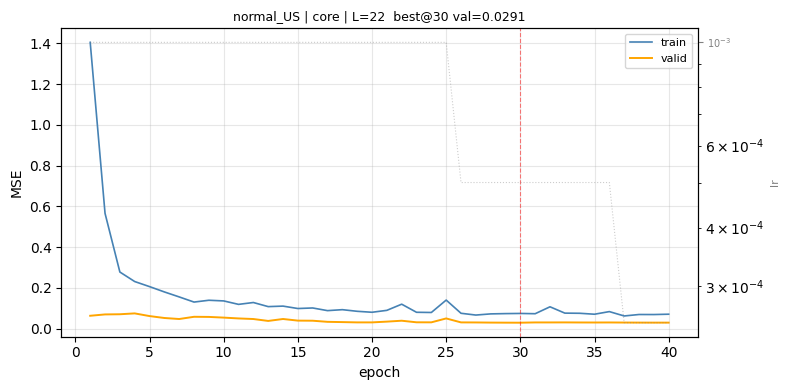

In [11]:
import matplotlib.pyplot as plt

def _load_history(protocol='static'):
    path = LOG_DIR / f'training_history_{protocol}.csv'
    if not path.exists():
        raise FileNotFoundError(f'history not found: {path}')
    return pd.read_csv(path)

def plot_one(regime, country, tier, L, protocol='static', refit_step=0, ax=None):
    """한 cell의 학습 곡선 (train/valid loss + lr 보조축)."""
    df = _load_history(protocol)
    cell = df[(df.regime==regime) & (df.country==country) & (df.feature_set==tier) &
              (df.L==L) & (df.refit_step==refit_step)]
    if cell.empty:
        print(f'no history for {regime}_{country}_{tier}_L{L} (protocol={protocol}, refit_step={refit_step})')
        return

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(cell.epoch, cell.train_loss, label='train', color='steelblue', lw=1.2)
    ax.plot(cell.epoch, cell.valid_loss, label='valid', color='orange', lw=1.4)
    best = cell.loc[cell.valid_loss.idxmin()]
    ax.axvline(best.epoch, color='red', linestyle='--', alpha=0.5, lw=0.8)
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE')
    ax.set_title(f'{regime}_{country} | {tier} | L={L}  best@{int(best.epoch)} val={best.valid_loss:.4f}',
                 fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    # lr 보조축
    ax2 = ax.twinx()
    ax2.plot(cell.epoch, cell.lr, color='gray', alpha=0.4, linestyle=':', lw=0.8)
    ax2.set_ylabel('lr', color='gray', fontsize=8)
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelsize=7, colors='gray')
    if own_fig:
        plt.tight_layout(); plt.show()

def plot_grid(tier, protocol='static', save_path=None):
    """한 tier 전체 (4 regime × 3 country × 3 L = 36 panel) grid plot."""
    fig, axes = plt.subplots(
        len(REGIMES) * len(LS), len(COUNTRIES),
        figsize=(14, 28), constrained_layout=True,
    )
    for r_i, regime in enumerate(REGIMES):
        for l_i, L in enumerate(LS):
            row = r_i * len(LS) + l_i
            for c_i, country in enumerate(COUNTRIES):
                plot_one(regime, country, tier, L, protocol=protocol, ax=axes[row, c_i])
    fig.suptitle(f'Training curves — tier={tier}, protocol={protocol}',
                 fontsize=14, weight='bold')
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'saved: {save_path}')
    plt.show()

# === 예시: 한 cell ===
plot_one('normal', 'US', 'core', L=22)

# === 예시: tier=core grid (모든 cell) ===
# plot_grid('core', protocol='static', save_path=LOG_DIR / 'curves_core_static.png')